# Gaussian comparison results

Plot saved comparison tables only. The plotting implementation is in
`examples/gaussian/analysis/plot.py`; no network evaluation or calibration is run here.

Each figure has candidate models M1–M4 in rows and L2, Linf, density, and kernel diagnostics in columns.
The PMP figures use the same y-axis range for direct and indirect methods.

In [1]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import sys

ROOT = next((p for p in (Path.cwd().resolve(), *Path.cwd().resolve().parents)
             if (p / "examples/gaussian/config.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("Open this notebook from inside the model_comparison_new repository.")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
from examples.gaussian.analysis.plot import load_runs, plot_metric_grid


In [2]:
NUM_OBS = 10
RESULT_DIR = ROOT / "examples/gaussian/results"
OUTPUT_DIR = RESULT_DIR / "plots" / f"n{NUM_OBS}"

indirect = load_runs("indirect", NUM_OBS, result_dir=RESULT_DIR,
                     summary_dims=(20, 40, 80))
direct = load_runs("direct", NUM_OBS, result_dir=RESULT_DIR,
                   summary_dims=(12,),
                   scoring_rules=("cross_entropy", "logistic", "exponential"))

# Check dataset identity across both methods before comparing figures.
key_columns = ["source_model", "id", "candidate_model"]
reference = next(iter(indirect.values())).set_index(key_columns).sort_index()
for label, frame in direct.items():
    aligned = frame.set_index(key_columns).sort_index()
    if not aligned.index.equals(reference.index):
        raise ValueError(f"Direct/indirect dataset mismatch: {label}")
    if "gold_pmp" in aligned and "gold_pmp" in reference:
        pd.testing.assert_series_equal(aligned.gold_pmp, reference.gold_pmp,
                                       check_exact=False, rtol=1e-10, atol=1e-12)

print("Indirect:", ", ".join(indirect))
print("Direct:", ", ".join(direct))
print("Figures:", OUTPUT_DIR)


Indirect: S=D, S=2D, S=4D
Direct: Cross-entropy (S=12), Logistic (S=12), Exponential (S=12)
Figures: /Users/yimingzang/Documents/Project/model_comparison/examples/gaussian/results/plots/n10


## Indirect: posterior MMD

Saved: /Users/yimingzang/Documents/Project/model_comparison/examples/gaussian/results/plots/n10/indirect/posterior_mmd_4x4.png


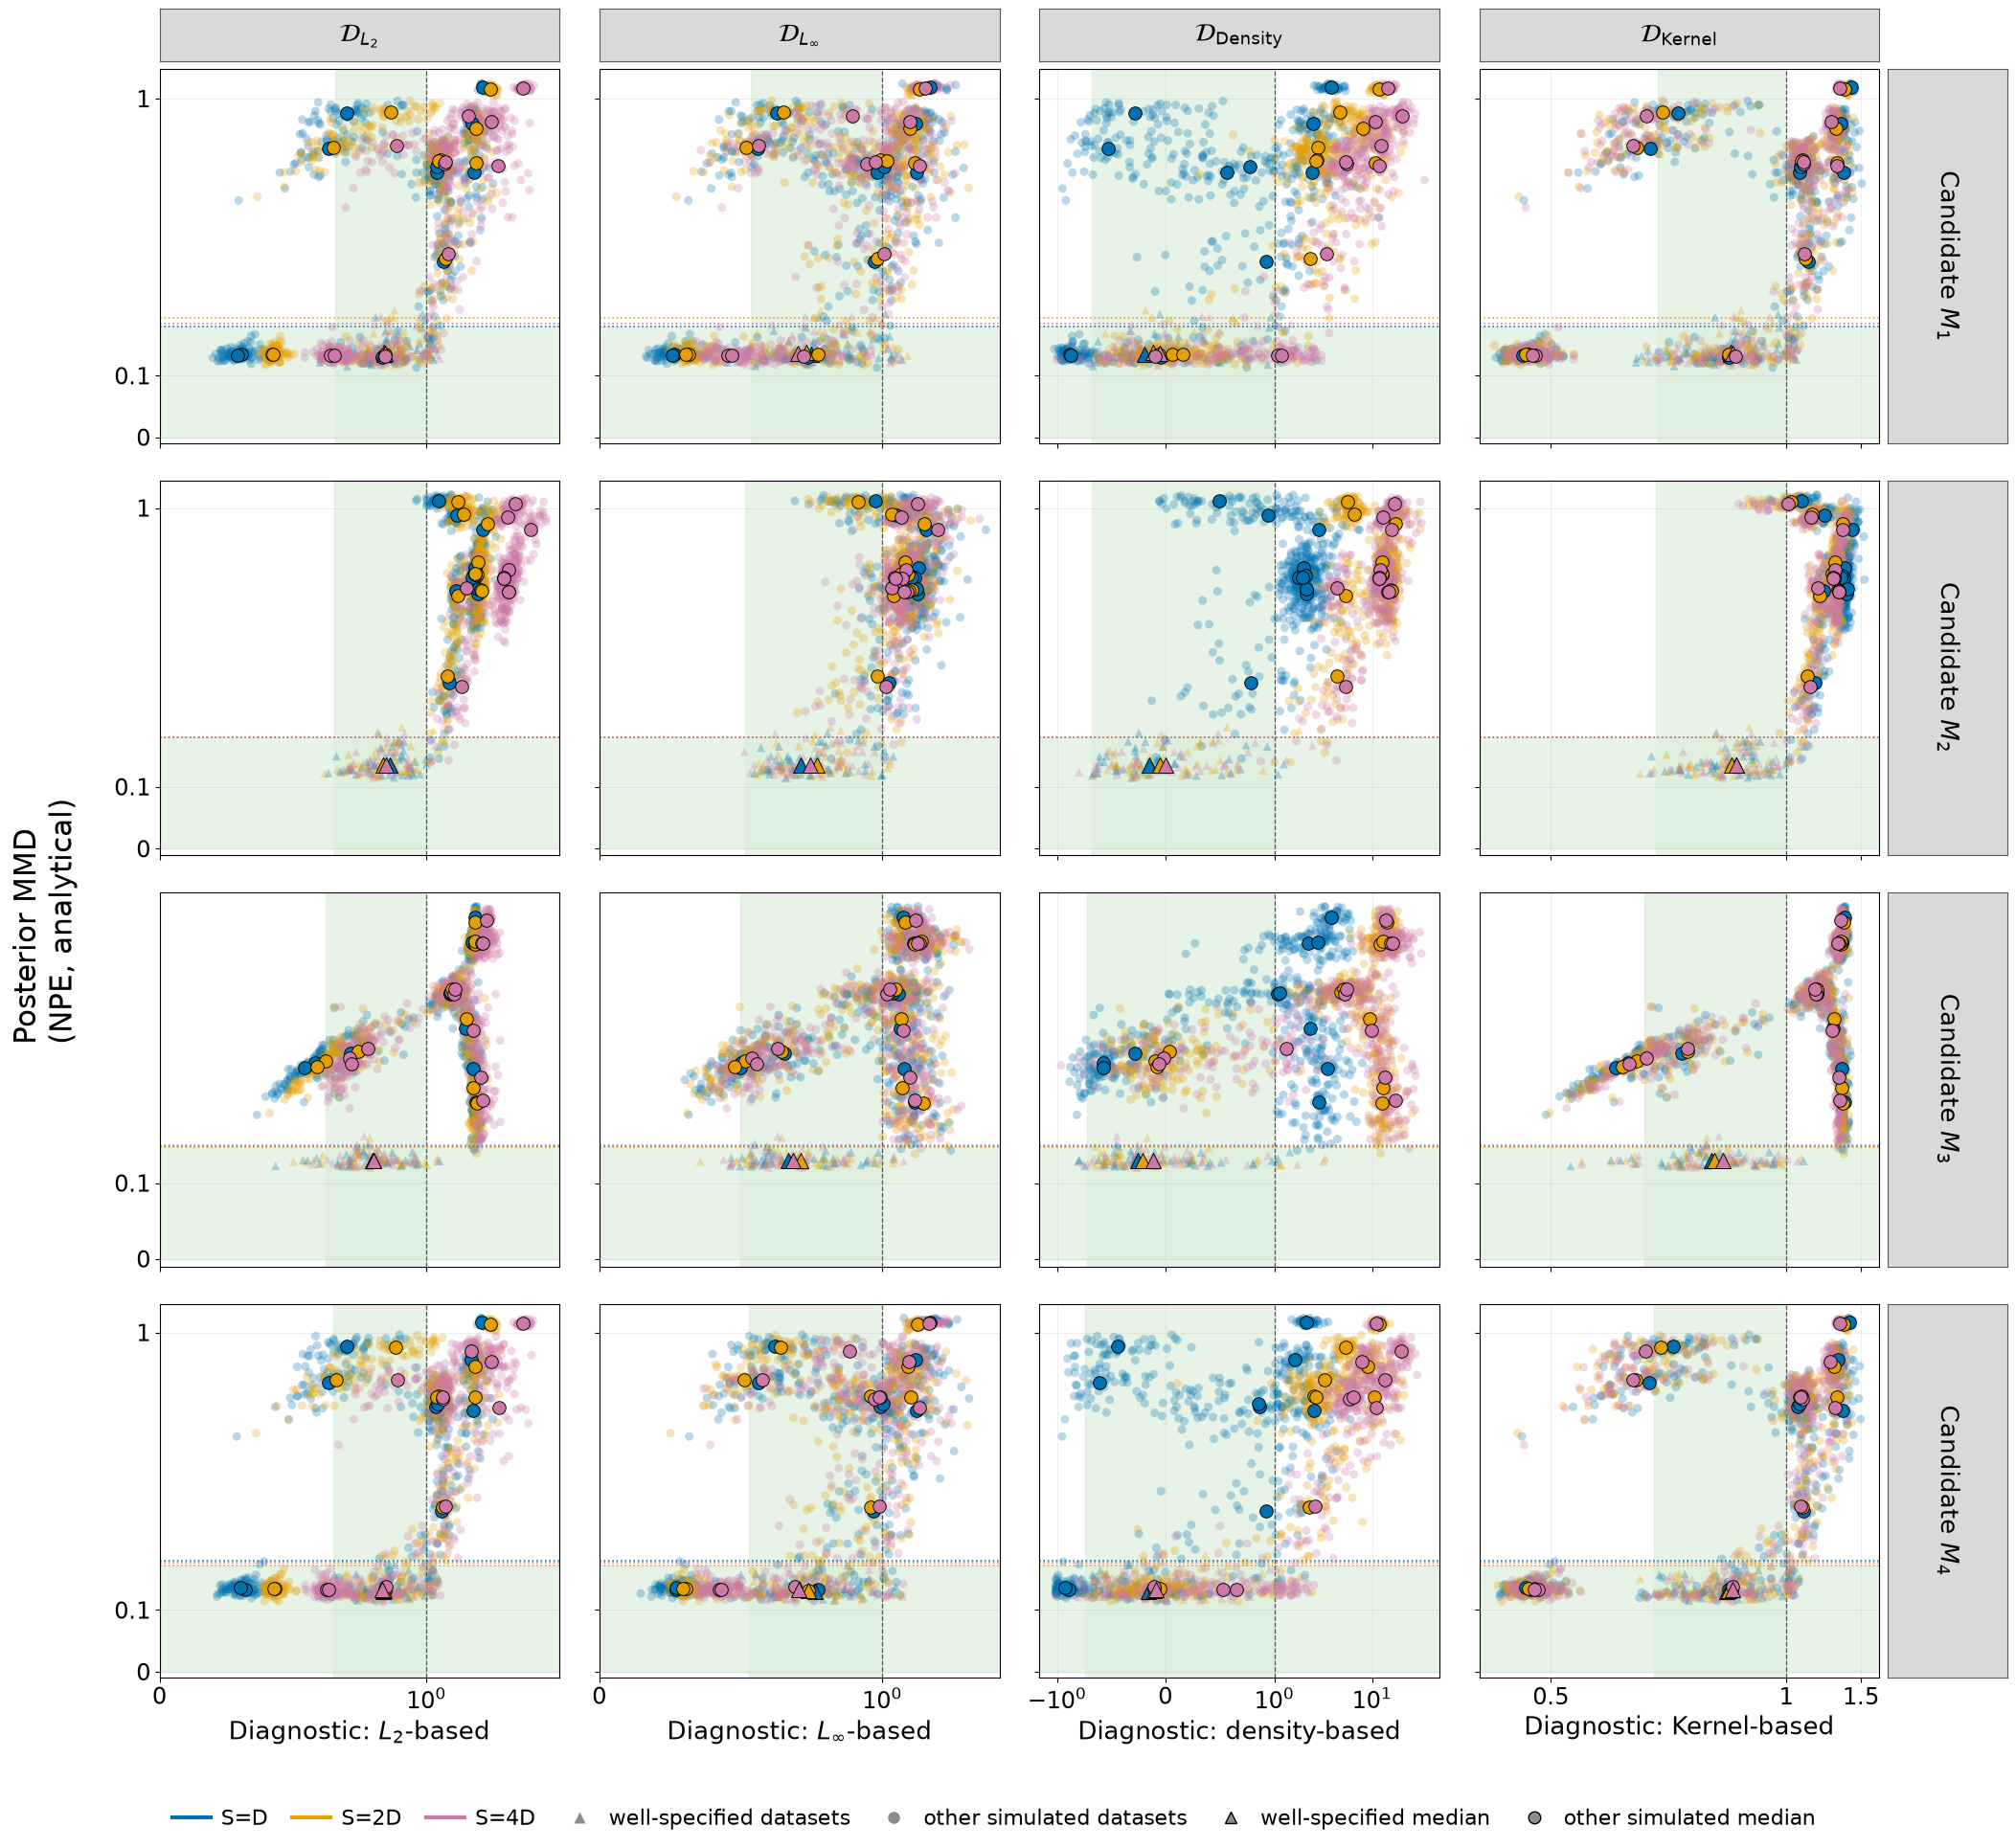

In [3]:
fig, axes = plot_metric_grid(
    indirect, "posterior_mmd",
    output=OUTPUT_DIR / "indirect" / "posterior_mmd_4x4.png",
)
display(fig)
plt.close(fig)


## Indirect: log10 marginal-likelihood error

Saved: /Users/yimingzang/Documents/Project/model_comparison/examples/gaussian/results/plots/n10/indirect/logml_4x4.png


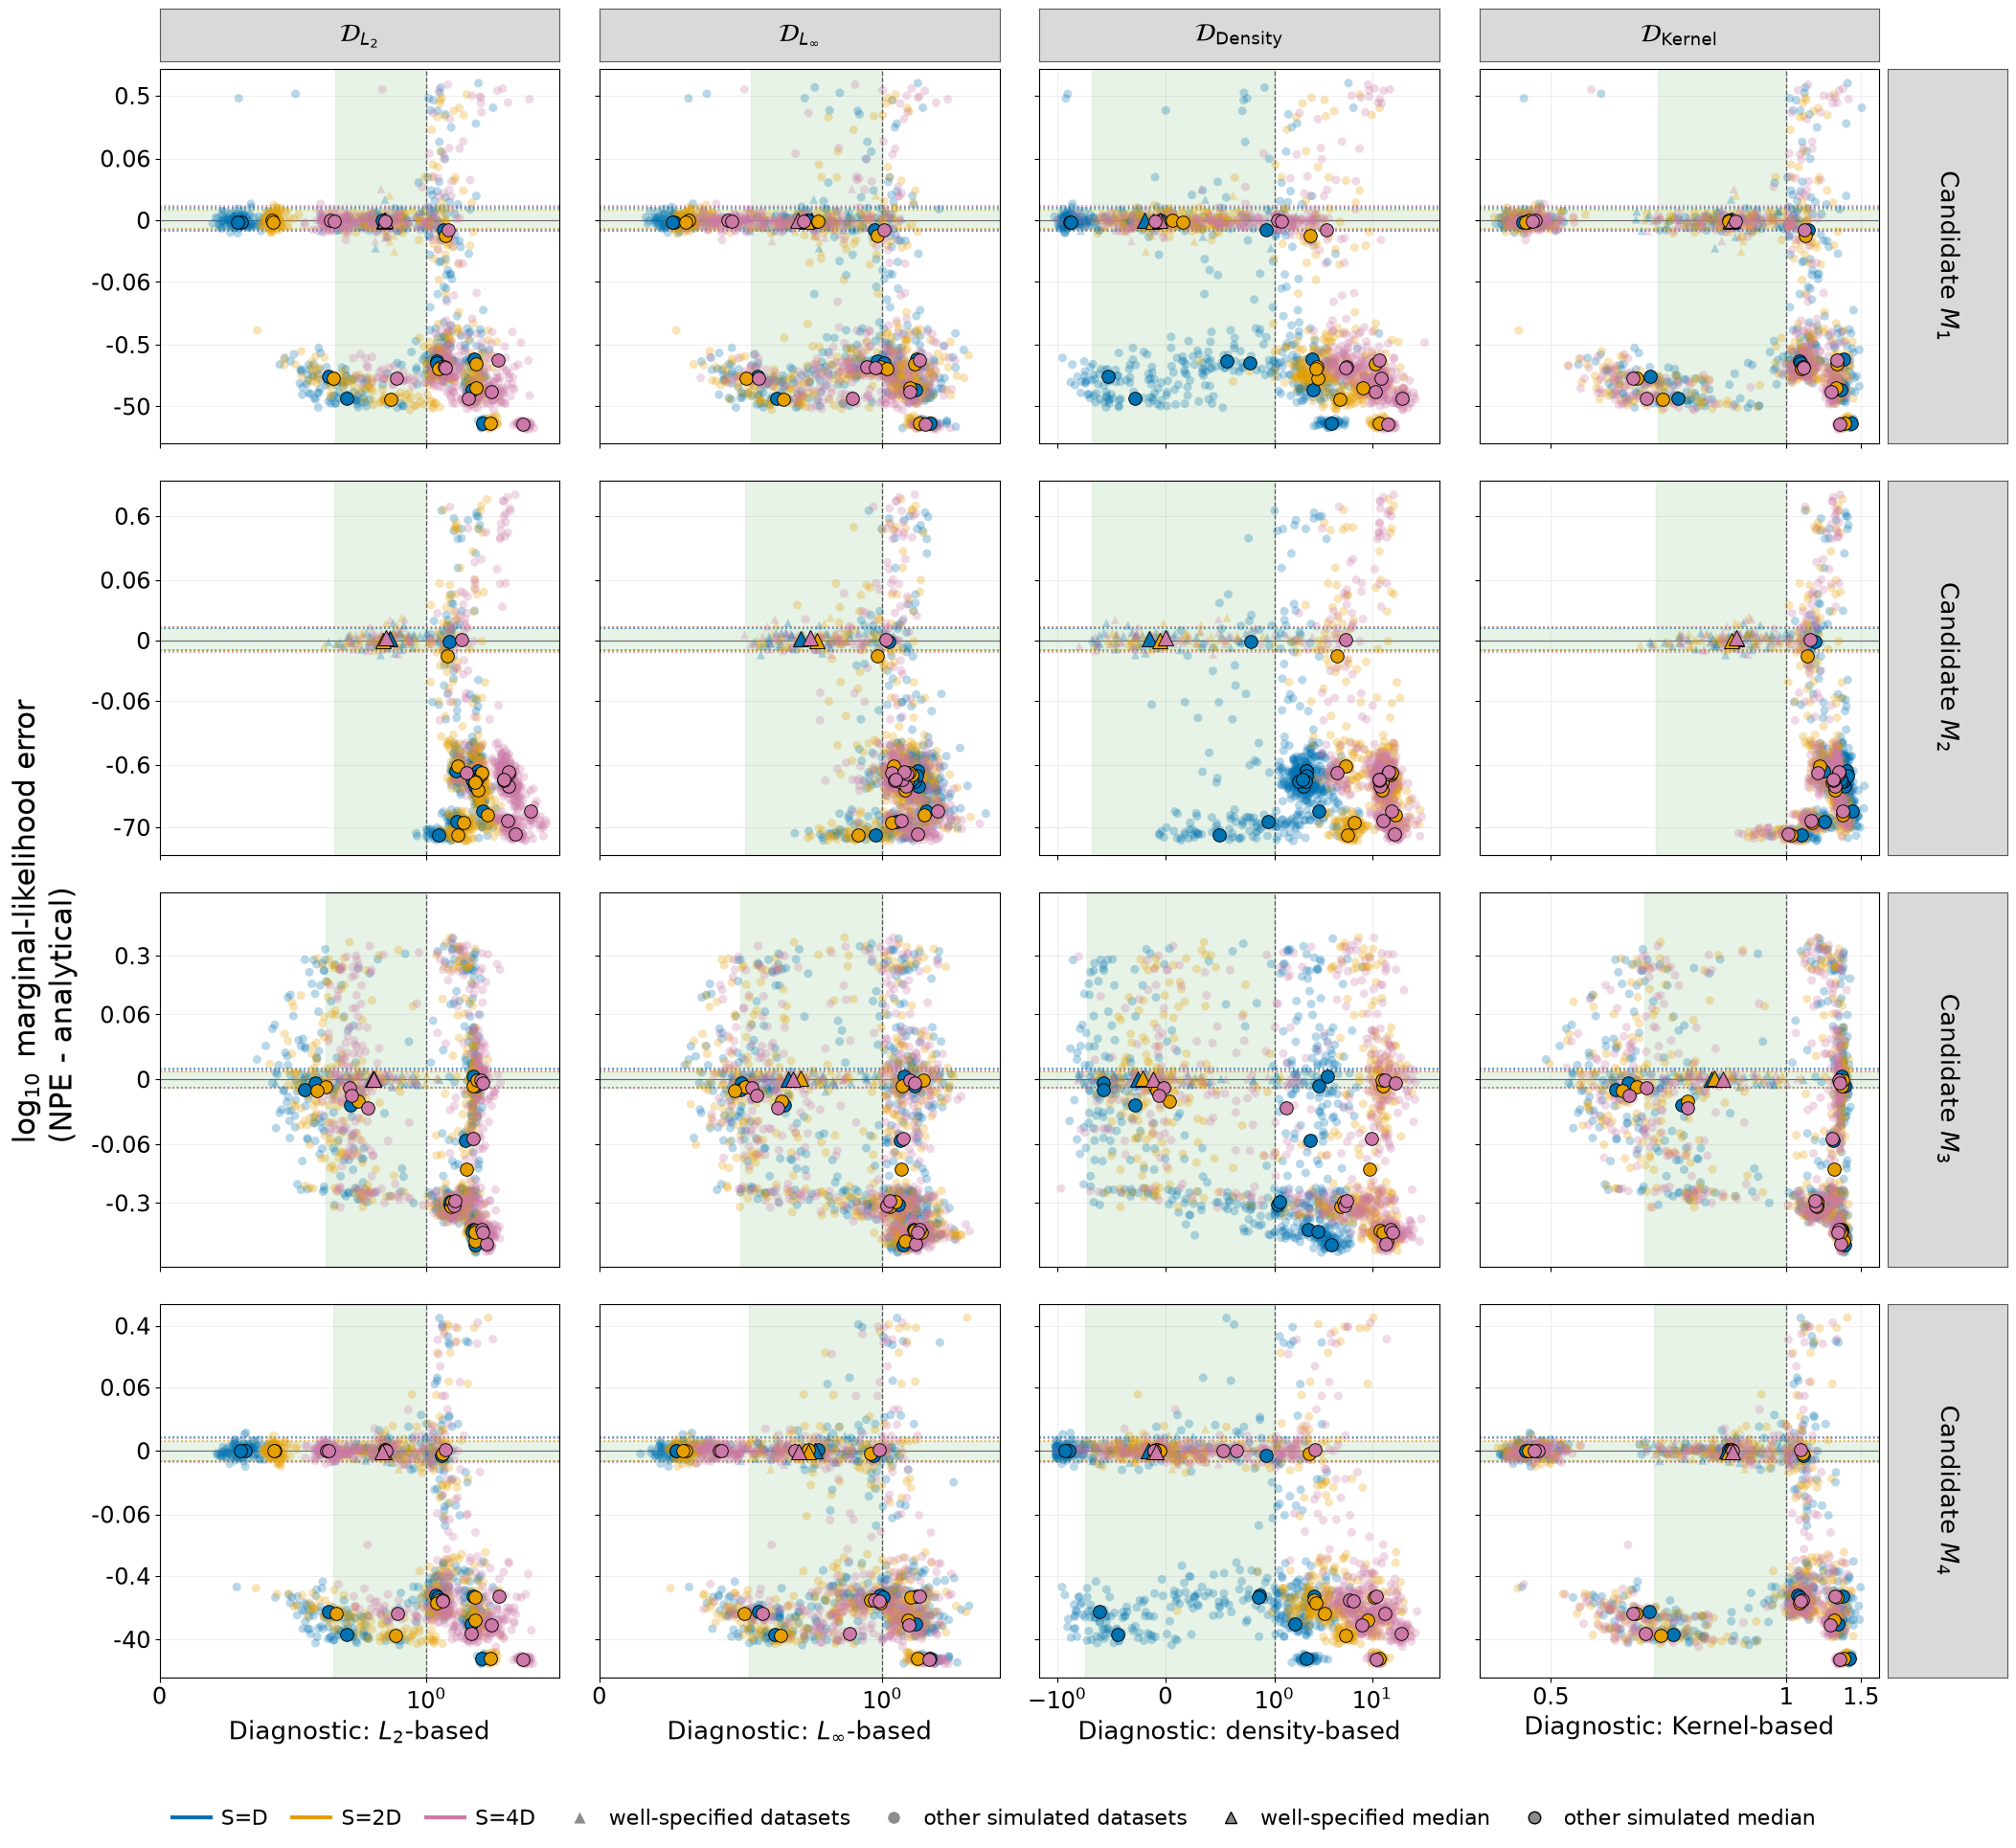

In [4]:
fig, axes = plot_metric_grid(
    indirect, "logml",
    output=OUTPUT_DIR / "indirect" / "logml_4x4.png",
)
display(fig)
plt.close(fig)


## Indirect: PMP error

Circles: all four candidates have rho > 1. Diamonds: at least one candidate has rho <= 1. This classification is recomputed from the saved rho columns, not from error thresholds.

Saved: /Users/yimingzang/Documents/Project/model_comparison/examples/gaussian/results/plots/n10/indirect/pmp_4x4.png


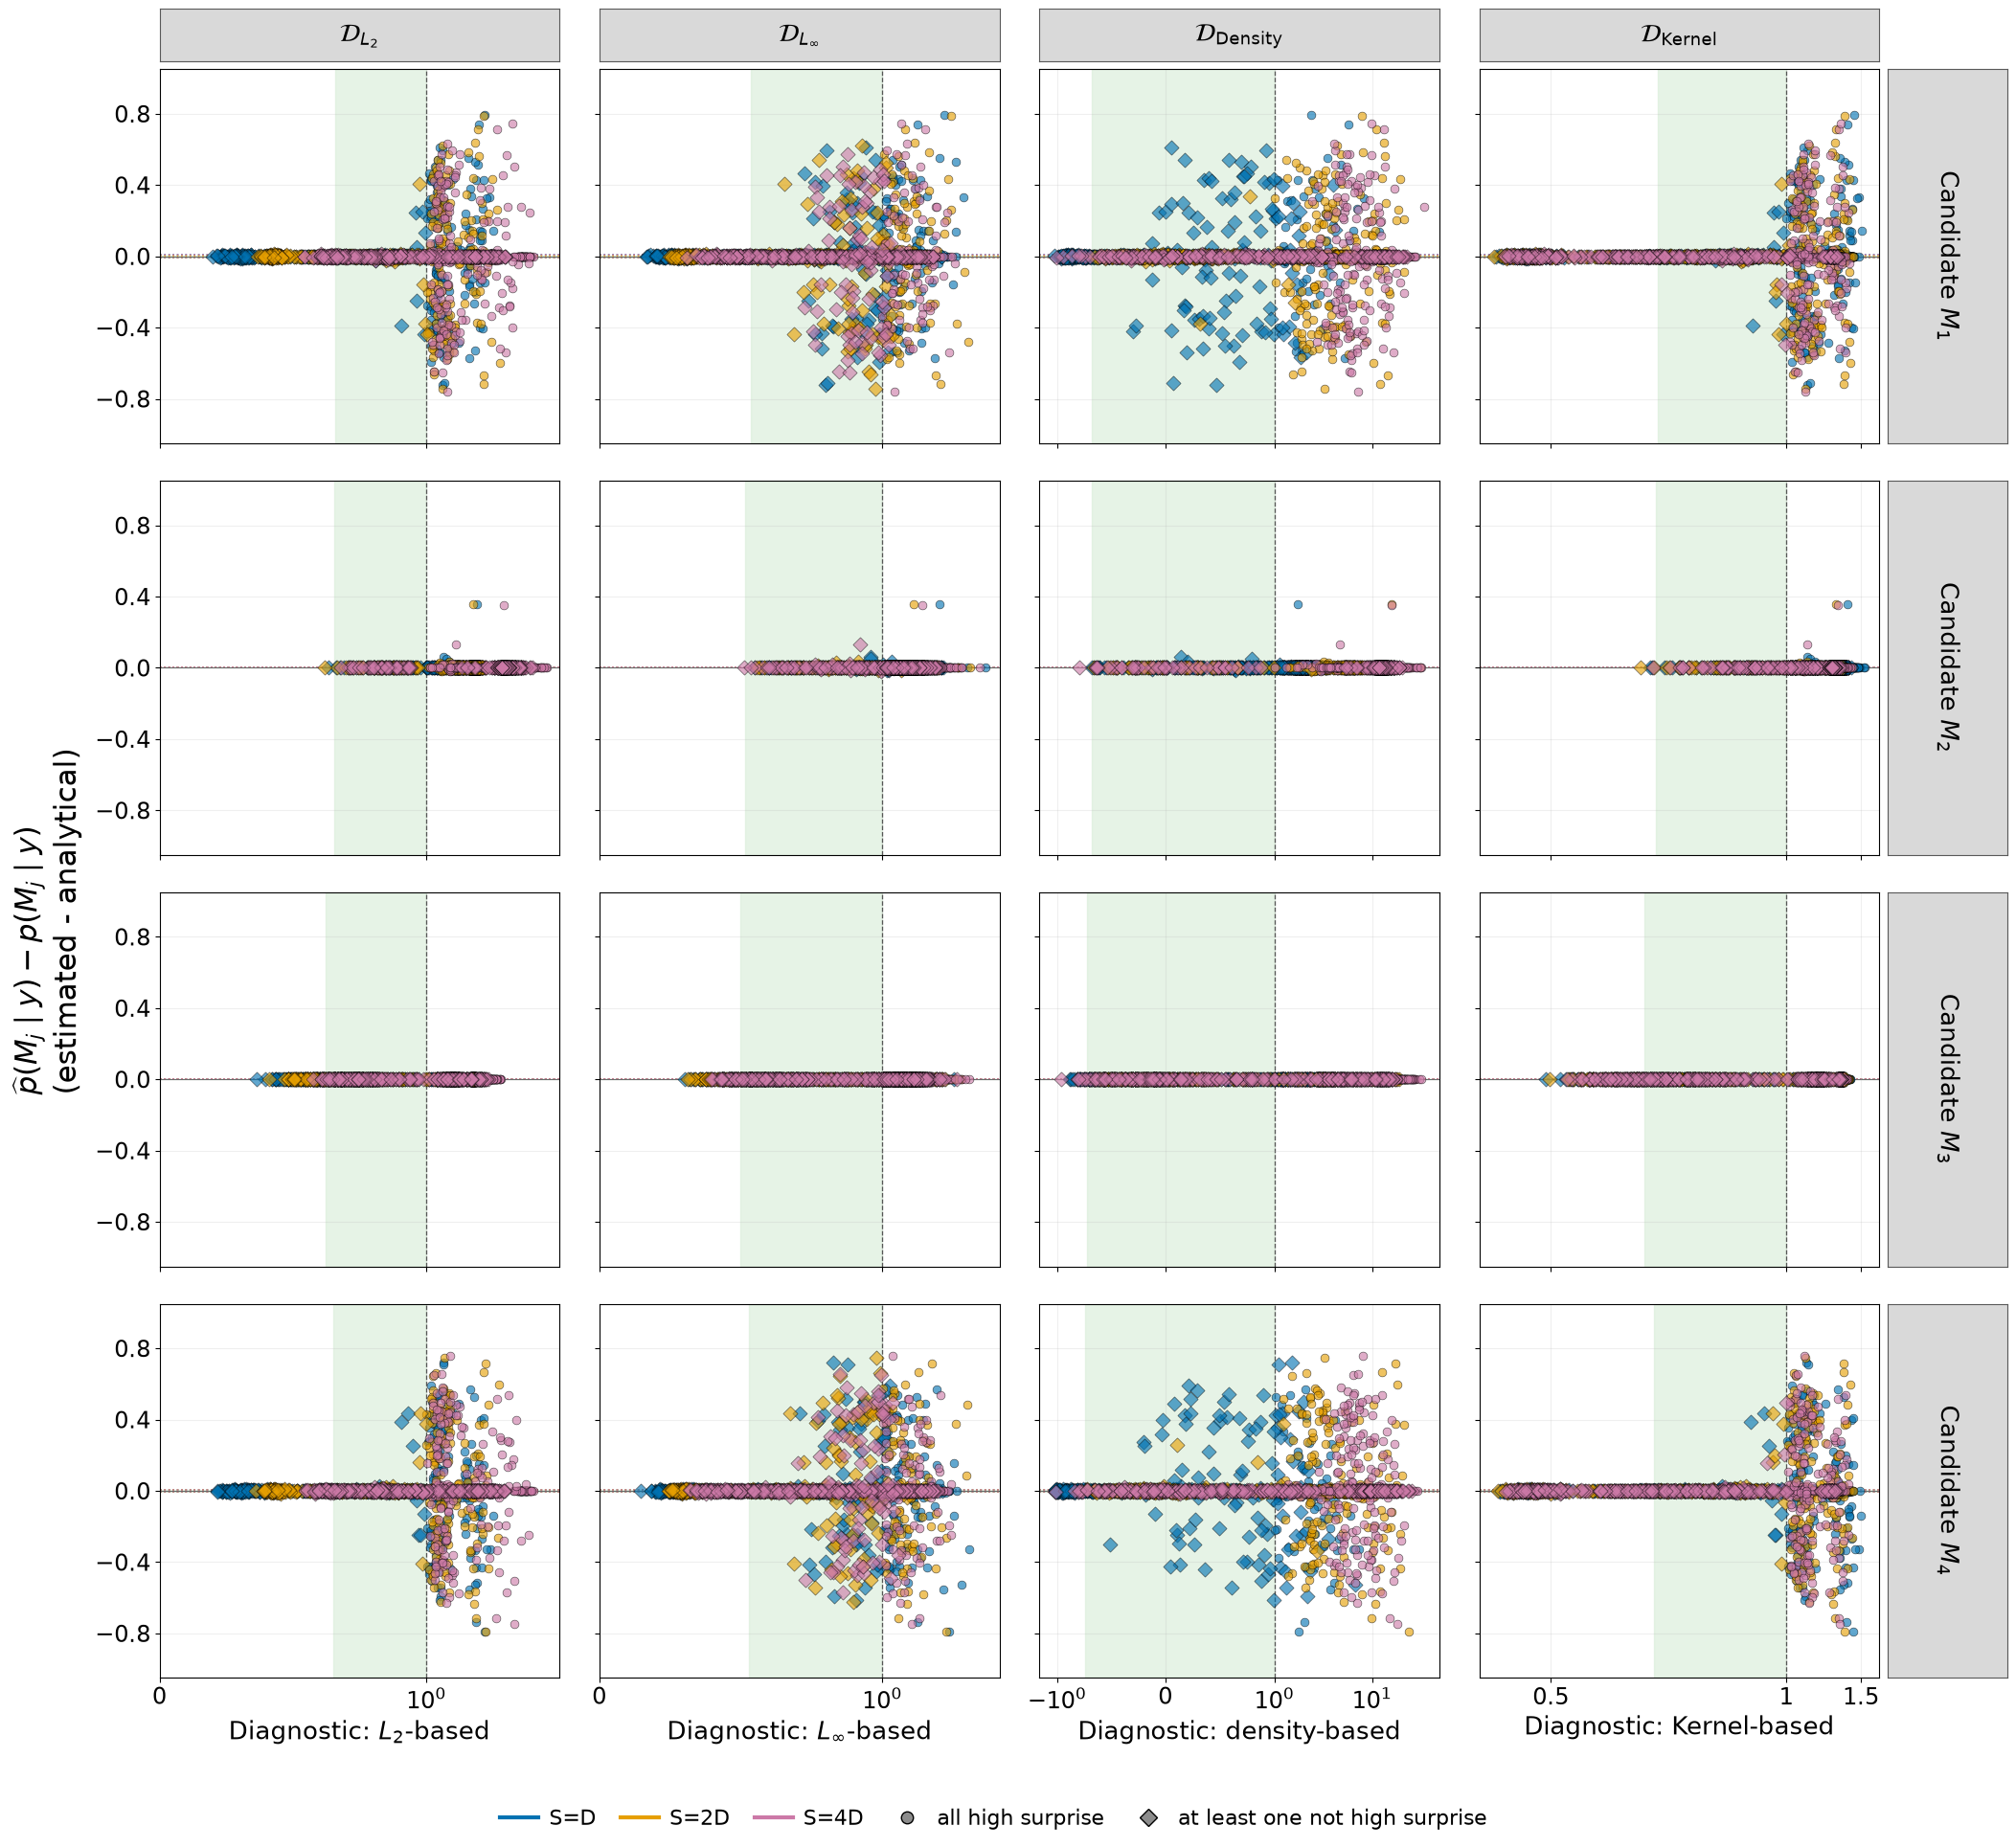

In [5]:
fig, axes = plot_metric_grid(
    indirect, "pmp",
    output=OUTPUT_DIR / "indirect" / "pmp_4x4.png",
    ylim=(-1.05, 1.05),
)
display(fig)
plt.close(fig)


## Direct: PMP error

Color encodes scoring rule. All points use a common marker; there is no cross-model surprise classification. For each dataset and loss, the same diagnostic x-value appears in all four PMP rows.

Saved: /Users/yimingzang/Documents/Project/model_comparison/examples/gaussian/results/plots/n10/direct/pmp_4x4.png


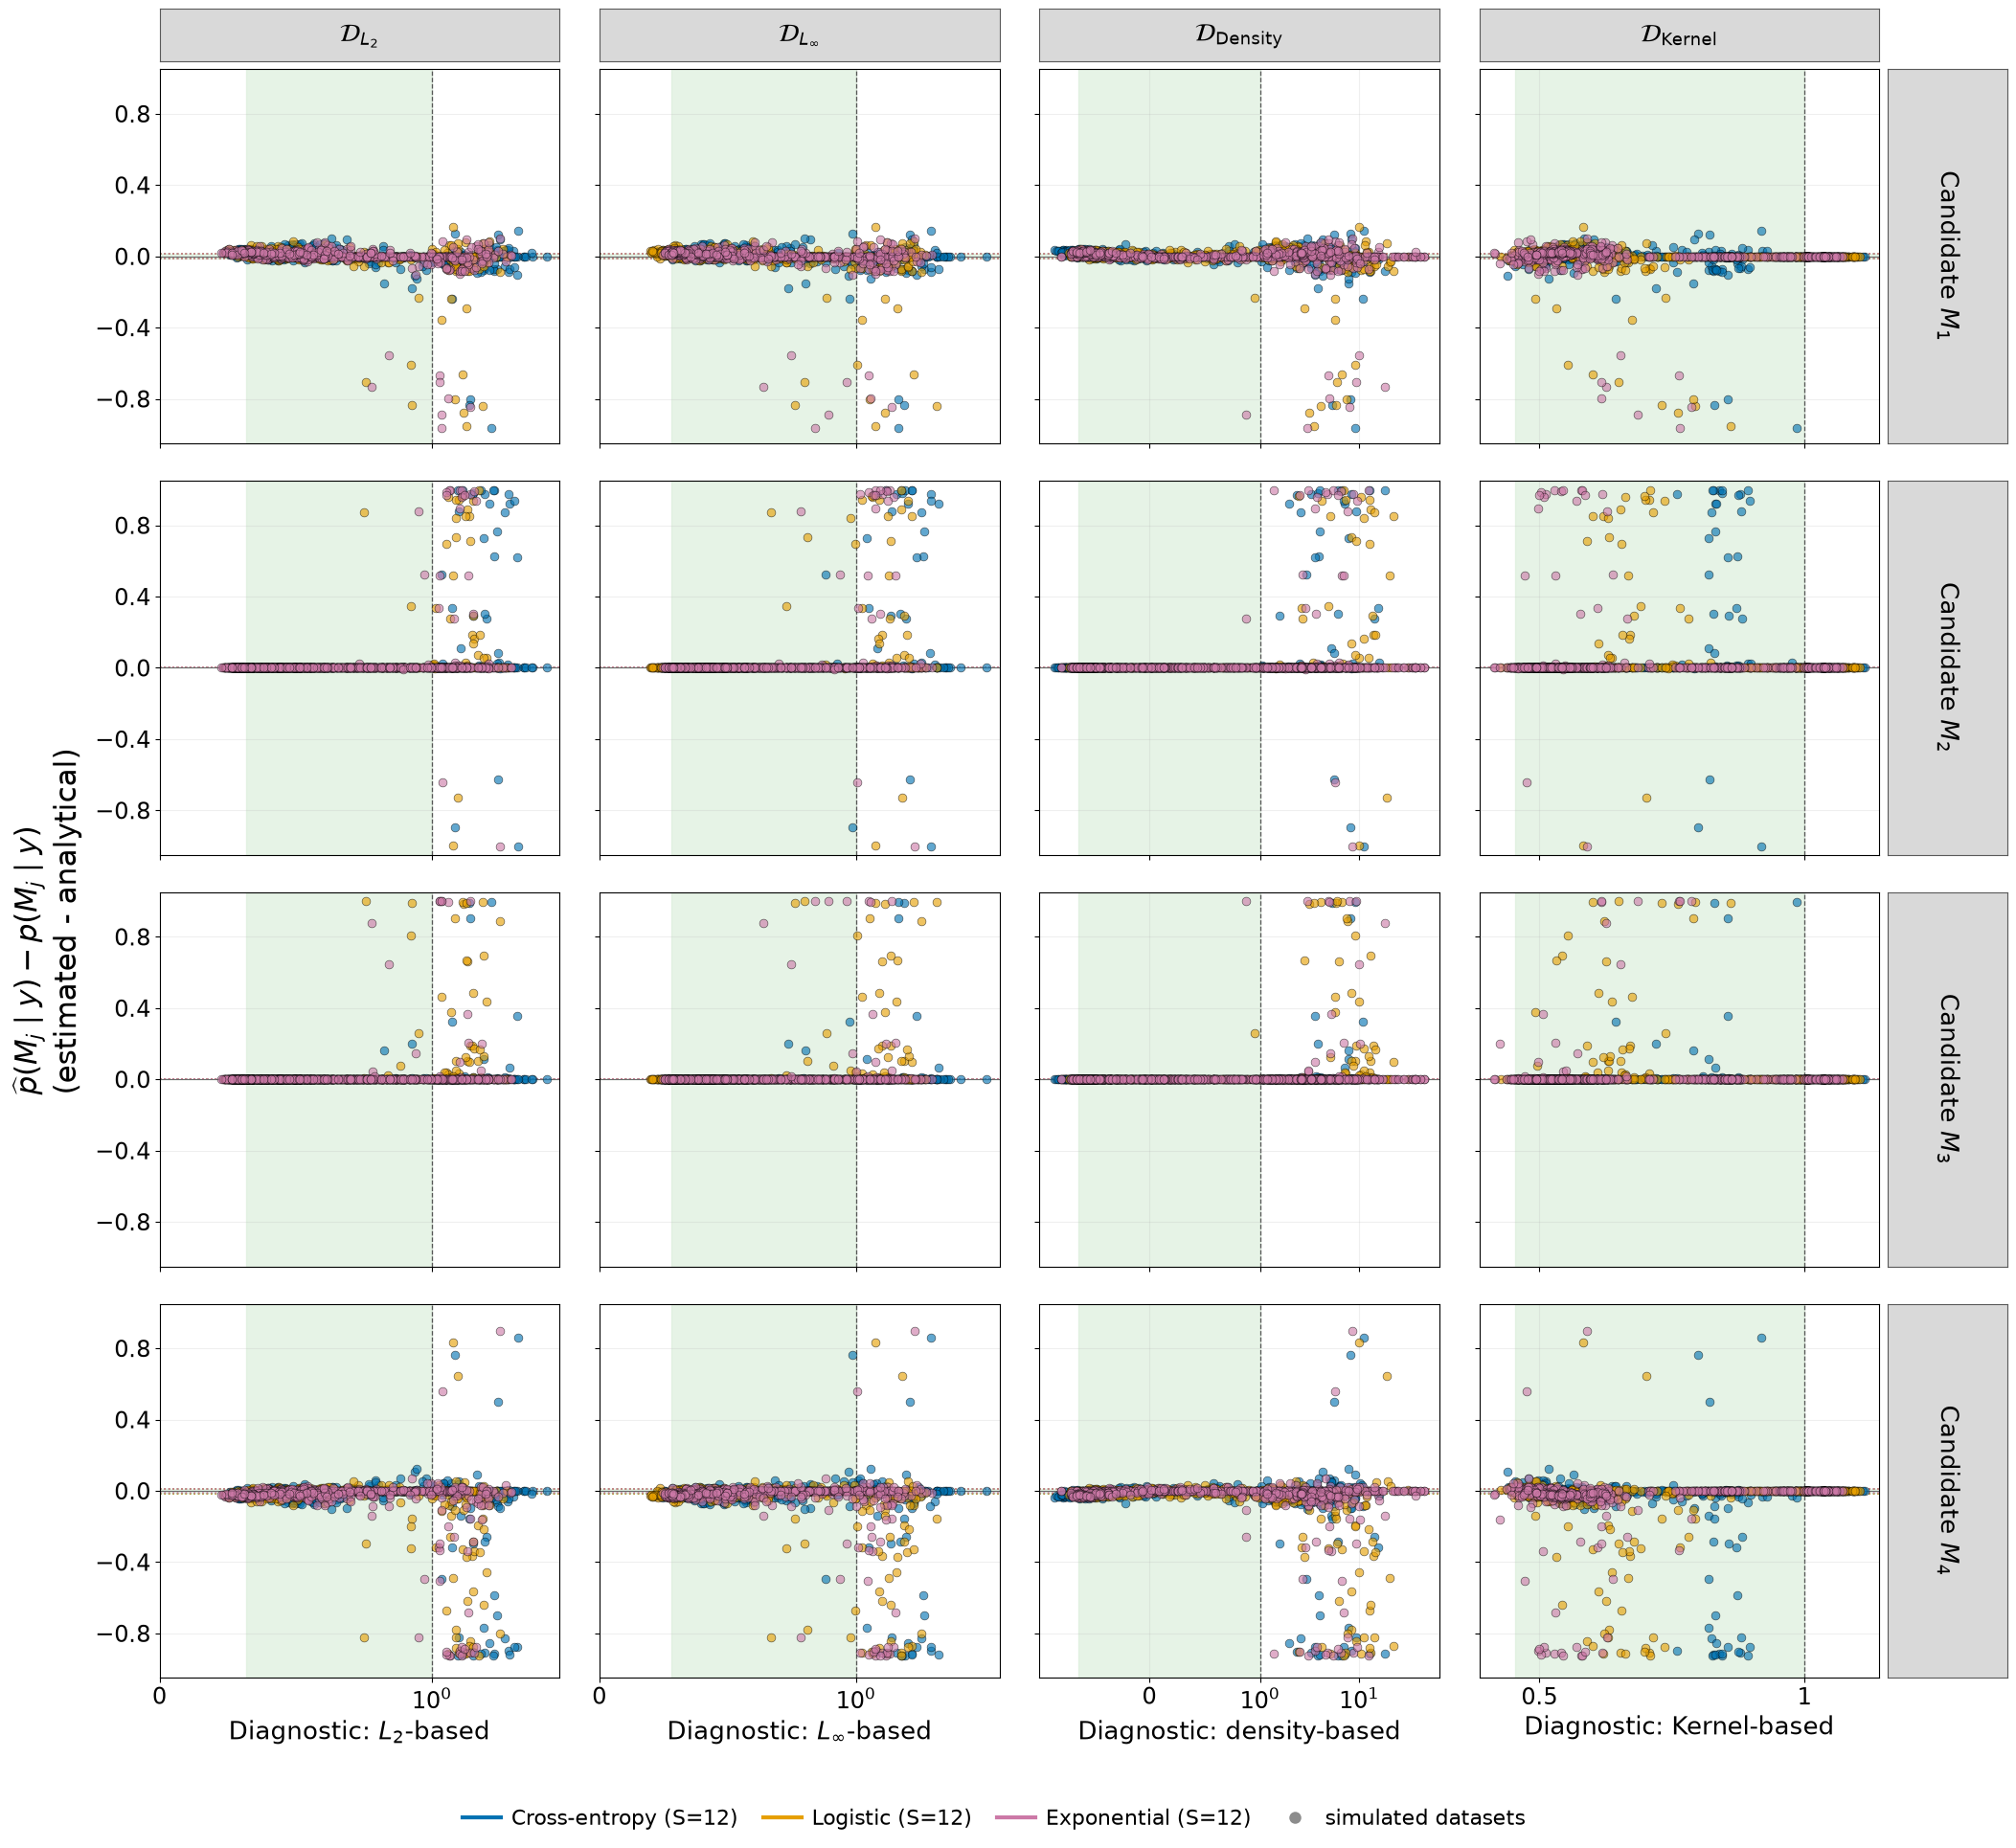

In [6]:
fig, axes = plot_metric_grid(
    direct, "pmp",
    output=OUTPUT_DIR / "direct" / "pmp_4x4.png",
    ylim=(-1.05, 1.05),
)
display(fig)
plt.close(fig)


## Existing detection metrics (optional)

These are read from `detection.csv`, not recalculated. Run-specific calibrated error thresholds can differ, so the tables do not by themselves establish which estimator is more accurate.

In [7]:
tables = []
for label, frame in {**indirect, **direct}.items():
    setting = frame.iloc[0]
    dim = int(setting["summary_dim"])
    name = (f"indirect_s{dim}" if setting["method"] == "indirect"
            else f"direct_{setting['scoring_rule']}_s{dim}")
    path = RESULT_DIR / "comparison" / f"n{NUM_OBS}" / name / "detection.csv"
    if path.is_file():
        tables.append(pd.read_csv(path).assign(run=label))
if tables:
    detection = pd.concat(tables, ignore_index=True)
    display(detection[["run", "candidate_model", "error_metric", "diagnostic",
                       "FNR", "FPR", "AUC"]].round(3))
else:
    print("No detection.csv files found; the four figures only require data.csv.")


,run,candidate_model,error_metric,diagnostic,FNR,FPR,AUC
0,S=D,m1,posterior_mmd,l2,0.281,0.065,0.884
1,S=D,m1,posterior_mmd,linf,0.456,0.035,0.874
2,S=D,m1,posterior_mmd,density,0.509,0.030,0.868
3,S=D,m1,posterior_mmd,mmd,0.281,0.065,0.885
4,S=D,m1,logml,l2,0.298,0.100,0.856
...,...,...,...,...,...,...,...
187,Exponential (S=12),m3,pmp,mmd,1.000,0.115,0.195
188,Exponential (S=12),m4,pmp,l2,0.775,0.137,0.404
189,Exponential (S=12),m4,pmp,linf,0.787,0.123,0.384
190,Exponential (S=12),m4,pmp,density,0.469,0.357,0.498
